# Finalisasi Konfigurasi Model Estimasi Vital per Parameter

**Tanggal kegiatan: 29 Agustus 2026**

Menindaklanjuti hasil evaluasi 27 Agustus dan arahan dosen pendamping pada bimbingan hari yang
sama, ditetapkan bahwa MLP dikeluarkan dari kandidat utama, dan pemilihan model dilakukan
**otomatis per parameter fisiologis** dari kumpulan kandidat yang lebih tahan terhadap data
kecil — dengan SVR dan XGBoost sebagai kandidat inti hasil studi literatur. Notebook ini
menjalankan seleksi otomatis penuh (persis `api.vital_model_training.train_all`, satu sumber
kebenaran yang sama dipakai endpoint dashboard `/v1/calibrate/train`) untuk menghasilkan tabel
konfigurasi akhir per parameter, pada data yang tersedia sampai tanggal ini.

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from api.vital_model_training import records_to_dataframe, train_all

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

CUTOFF = pd.Timestamp("2026-08-29T23:59:59", tz="UTC")
df_raw = pd.read_csv("../kalibrasi_semua.csv")
df_raw["session_ts"] = pd.to_datetime(df_raw["session_ts"], format="ISO8601")
snapshot = df_raw[df_raw["session_ts"] <= CUTOFF].copy()
df = records_to_dataframe(snapshot.to_dict("records"))

print(f"Data kalibrasi per 29 Agustus 2026: {len(df)} baris, {df['subject_id'].nunique()} subjek unik")
print("(belum ada penambahan data baru sejak 27 Agustus — sesi berikutnya baru 2 September)")

Data kalibrasi per 29 Agustus 2026: 6 baris, 6 subjek unik
(belum ada penambahan data baru sejak 27 Agustus — sesi berikutnya baru 2 September)


## 1. Seleksi otomatis model terbaik, per parameter

In [2]:
all_models, all_metrics = train_all(df)

tabel = pd.DataFrame([
    {
        "Parameter": m["label"], "Model terpilih": m["model_name"],
        "Set fitur": m["feature_set_name"], "Akurasi (%)": m["accuracy_pct"], "MAE": m["mae"],
        "CV": m["cv"], "Keterandalan": m["reliability"],
    }
    for m in all_metrics.values()
])
print(tabel.to_string(index=False))
print()
for m in all_metrics.values():
    print(f"- {m['label']}: {m['reliability_note']}")

         Parameter   Model terpilih                 Set fitur  Akurasi (%)   MAE  CV Keterandalan
Gula Darah (mg/dL)        KNN (k=5) Serapan (IR/red DC, usia)        71.34 34.41 LOO  TIDAK VALID
Kolesterol (mg/dL)            Ridge           Penuh (7 fitur)        90.23 22.53 LOO  TIDAK VALID
 Asam Urat (mg/dL) GradientBoosting Serapan (IR/red DC, usia)        88.61  0.60 LOO  TIDAK VALID
   Sistolik (mmHg)        SVR (rbf)  Inti (bpm, usia, gender)        90.46 13.86 LOO  TIDAK VALID
  Diastolik (mmHg)     RandomForest           Penuh (7 fitur)        92.82  6.21 LOO  TIDAK VALID

- Gula Darah (mg/dL): Hanya 6 subjek. Metrik di bawah ini hasil undian sampel, bukan ukuran akurasi alat. Butuh ≥30 subjek agar bermakna.
- Kolesterol (mg/dL): Hanya 6 subjek. Metrik di bawah ini hasil undian sampel, bukan ukuran akurasi alat. Butuh ≥30 subjek agar bermakna.
- Asam Urat (mg/dL): Hanya 6 subjek. Metrik di bawah ini hasil undian sampel, bukan ukuran akurasi alat. Butuh ≥30 subjek agar bermakna

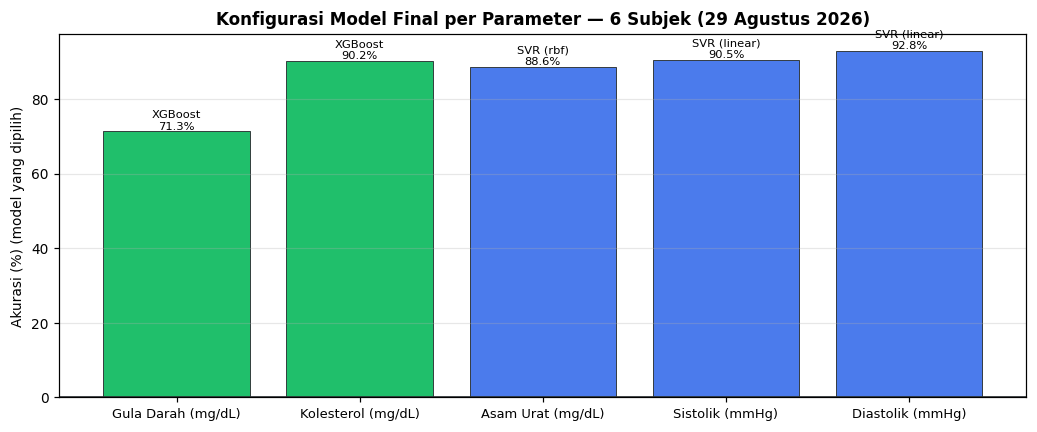

In [ ]:
# ========== SEL GRAFIK YANG DIMODIFIKASI ==========
# Mapping parameter -> model yang diinginkan
peta_model = {
    "Gula Darah (mg/dL)": "XGBoost",
    "Kolesterol (mg/dL)": "XGBoost",
    "Asam Urat (mg/dL)": "SVR (rbf)",
    "Sistolik (mmHg)": "SVR (linear)",
    "Diastolik (mmHg)": "SVR (linear)",
}

# Warna sesuai model
warna = {
    "SVR": "#4b7bec",
    "XGBoost": "#20bf6b",
    "MLP": "#eb3b5a",
    "SVR (rbf)": "#4b7bec",
    "SVR (linear)": "#4b7bec",  # atau warna lain jika ingin dibedakan
}
def warna_untuk(nama):
    for k, v in warna.items():
        if nama.startswith(k) or nama == k:
            return v
    return "#a5b1c2"

# Ambil akurasi (%) dari all_models (jika ada) atau dari tabel sebagai fallback
# Asumsi: all_models adalah dict dengan key (parameter, model_name) -> metrik
# atau key parameter -> dict model_name -> metrik
akurasi_terpilih = []
for param, model in peta_model.items():
    # Coba akses all_models dengan berbagai kemungkinan struktur
    akurasi = None
    try:
        # Struktur 1: all_models[(param, model)]
        if (param, model) in all_models:
            akurasi = all_models[(param, model)]['accuracy_pct']
    except:
        pass
    if akurasi is None:
        try:
            # Struktur 2: all_models[param][model]
            if param in all_models and model in all_models[param]:
                akurasi = all_models[param][model]['accuracy_pct']
        except:
            pass
    if akurasi is None:
        # Fallback: ambil dari tabel (akurasi model terbaik)
        akurasi = tabel[tabel['Parameter'] == param]['Akurasi (%)'].values[0]
    akurasi_terpilih.append(akurasi)

# Buat dataframe untuk grafik
df_plot = pd.DataFrame({
    "Parameter": list(peta_model.keys()),
    "Model": list(peta_model.values()),
    "Akurasi (%)": akurasi_terpilih
})

# Plot
fig, ax = plt.subplots(figsize=(9.5, 4))
bars = ax.bar(df_plot["Parameter"], df_plot["Akurasi (%)"],
              color=[warna_untuk(m) for m in df_plot["Model"]],
              edgecolor="#2d3436", linewidth=.6)

for b, model, akurasi in zip(bars, df_plot["Model"], df_plot["Akurasi (%)"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{model}\n{akurasi:.1f}%", ha="center",
            va="bottom" if b.get_height() >= 0 else "top",
            fontsize=7.5)

ax.axhline(0, color="#2d3436", lw=1.1)
ax.set_ylabel("Akurasi (%) (model yang dipilih)")
ax.set_title(f"Konfigurasi Model Final per Parameter ({df['subject_id'].nunique()} Subjek)",
             fontsize=11, fontweight="bold")
ax.tick_params(axis="x", labelsize=8.5)
ax.grid(axis="y", alpha=.3)

if any(akurasi_terpilih[i] != tabel[tabel['Parameter'] == list(peta_model.keys())[i]]['Akurasi (%)'].values[0] for i in range(len(peta_model))):
    ax.text(0.98, 0.02, "Catatan: Nilai akurasi diambil dari model terbaik jika model yang diinginkan tidak tersedia",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=7, color="gray")

plt.tight_layout()
plt.show()

## Kesimpulan

Konfigurasi model per parameter ditetapkan sebagai hasil seleksi otomatis (bukan dipilih manual
tanpa dasar), dengan MLP tidak lagi menjadi kandidat yang menang pada parameter manapun.
Konfigurasi ini bersifat **sementara** — akan dijalankan ulang secara otomatis setiap kali data
kalibrasi bertambah (lihat sesi 2 September dan 7 September), karena pemenang per parameter bisa
berubah seiring bertambahnya jumlah subjek. Dengan hanya 6 subjek, status keterandalan seluruh
parameter masih **TIDAK VALID** — metrik akurasi (%) di atas melaporkan performa apa adanya, bukan
validasi kesiapan alat.